<a href="https://colab.research.google.com/github/quiottaso01-alt/4-IAR---Dist---Noc---A---PROCESAMIENTO-DE-HABLA/blob/main/trabajo_PDF_Ivan_Quiottaso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Procesamiento de PDF y Análisis de Texto

## 1. Adquisición y Metadatos




En esta sección descargo un archivo PDF desde internet y analizo sus metadatos.

In [ ]:
import requests

url = "https://arxiv.org/pdf/2108.13418.pdf"
filename = "archivo.pdf"

response = requests.get(url)

with open(filename, "wb") as f:
    f.write(response.content)

print("PDF descargado correctamente")

PDF descargado correctamente


In [ ]:
!pip install PyMuPDF
import fitz  # PyMuPDF

doc = fitz.open("archivo.pdf")

print("Título:", doc.metadata["title"])
print("Autor:", doc.metadata["author"])
print("Páginas:", doc.page_count)
print("Software:", doc.metadata["creator"])

Título: 
Autor: 
Páginas: 26
Software: LaTeX with hyperref


Utilicé la librería PyMuPDF para obtener los metadatos del documento.

En el campo "autor" no se obtuvo información. Esto puede ocurrir porque algunos archivos PDF no tienen completos sus metadatos internos, aunque los autores sí estén visibles dentro del contenido del documento.

Esto permite conocer información importante como el título, la cantidad de páginas y el software con el que fue creado.

## 2. Análisis estructural del texto

En esta sección extraigo el texto de las primeras páginas y analizo cómo está estructurado.

In [ ]:
texto = ""

for i in range(5):
    page = doc[i]
    texto += page.get_text()

print(texto[:1500])

1
Version October 18, 2021
Preprint typeset using LATEX style openjournal v. 09/06/15
THE LSST-DESC 3X2PT TOMOGRAPHY OPTIMIZATION CHALLENGE
Joe Zuntz1, Fran¸cois Lanusse2, Alex I. Malz3, Angus H. Wright3, Anˇze Slosar4, Bela Abolfathi5, David
Alonso6, Abby Bault5, Cl´ecio R. Bom78, Massimo Brescia9, Adam Broussard10, Jean-Eric Campagne11, Stefano
Cavuoti91213, Eduardo S. Cypriano14, Bernardo M. O. Fraga7, Eric Gawiser10, Elizabeth J. Gonzalez71516,
Dylan Green5, Peter Hatfield6, Kartheik Iyer17, David Kirkby5, Andrina Nicola18, Erfan Nourbakhsh19, Andy
Park5, Gabriel Teixeira7, Katrin Heitmann20, Eve Kovacs20, Yao-Yuan Mao21,
(The LSST Dark Energy Science Collaboration, LSST DESC)
Version October 18, 2021
ABSTRACT
This paper presents the results of the Rubin Observatory Dark Energy Science Collaboration
(DESC) 3x2pt tomography challenge, which served as a ﬁrst step toward optimizing the tomographic
binning strategy for the main DESC analysis. The task of choosing an optimal tomographic

#¿Qué caracteres especiales funcionan como separadores de línea o de bloque en este archivo específico?

Se extrajo el texto de las primeras 5 páginas del documento utilizando la función get_text() de la librería PyMuPDF.

Para facilitar la lectura, se muestra solo una parte del contenido de cada página, aunque el texto completo fue almacenado en una variable.

El texto se presenta de forma cruda, sin formato visual.

Se observan saltos de línea (\n) que separan los bloques de texto, así como múltiples espacios entre palabras.

También se detectan caracteres especiales como ligaduras (por ejemplo "ﬁ") y palabras separadas por guiones.

Esto ocurre porque la librería extrae el contenido directamente desde la estructura interna del PDF, sin reconstruir el formato original del documento.

## 3. Extracción de datos tabulares

En esta sección busco una tabla dentro del PDF y la convierto en un DataFrame.

In [ ]:
!pip install pdfplumber

import pdfplumber
import pandas as pd

with pdfplumber.open("archivo.pdf") as pdf:
    page = pdf.pages[6]  # página 7 real
    table = page.extract_table()

if table:
    df = pd.DataFrame(table[1:], columns=table[0])
    print("Tabla encontrada en la página 7:")
    print(df.head())
else:
    print("No se encontró ninguna tabla en la página 7.")

df.dropna(how='all', inplace=True)

df.head()

Tabla encontrada en la página 7:
                                                      \
0                                             Method   
1  ComplexSOM\nJaxCNN\nJaxResNet\nNeuralNetwork1\...   
2  AutokerasLSTM\nCNN\nENSEMBLE\nFunBins\nGPzBinn...   

                                                 riz  \
0                            3-bin 5-bin 7-bin 9-bin   
1  38.0 52.1 94.4 101.6\n59.9 101.9 105.2 –\n73.7...   
2  31.1 74.9 103.4 –\n27.1 50.8 76.7 103.3\n65.6 ...   

                                                griz  
0                            3-bin 5-bin 7-bin 9-bin  
1  34.9 45.0 91.6 100.3\n79.7 125.2 150.0 –\n82.2...  
2  44.1 67.5 122.2 98.4\n30.5 57.7 95.4 122.4\n* ...  


,,riz,griz
0,Method,3-bin 5-bin 7-bin 9-bin,3-bin 5-bin 7-bin 9-bin
1,ComplexSOM\nJaxCNN\nJaxResNet\nNeuralNetwork1\...,38.0 52.1 94.4 101.6\n59.9 101.9 105.2 –\n73.7...,34.9 45.0 91.6 100.3\n79.7 125.2 150.0 –\n82.2...
2,AutokerasLSTM\nCNN\nENSEMBLE\nFunBins\nGPzBinn...,31.1 74.9 103.4 –\n27.1 50.8 76.7 103.3\n65.6 ...,44.1 67.5 122.2 98.4\n30.5 57.7 95.4 122.4\n* ...


Se identificó una tabla en la página 7 del documento.

Se utilizó la librería pdfplumber para extraer la tabla y convertirla en un DataFrame de Pandas.

La tabla presenta algunas irregularidades, como múltiples valores dentro de una misma celda separados por saltos de línea (\n). Esto ocurre porque el PDF no almacena la tabla como una estructura real, sino como elementos visuales.

A pesar de esto, la extracción permite representar los datos de forma estructurada para su análisis.

## 4. Análisis de frecuencias

En esta sección analizo las palabras más frecuentes del texto utilizando técnicas básicas de NLP.

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


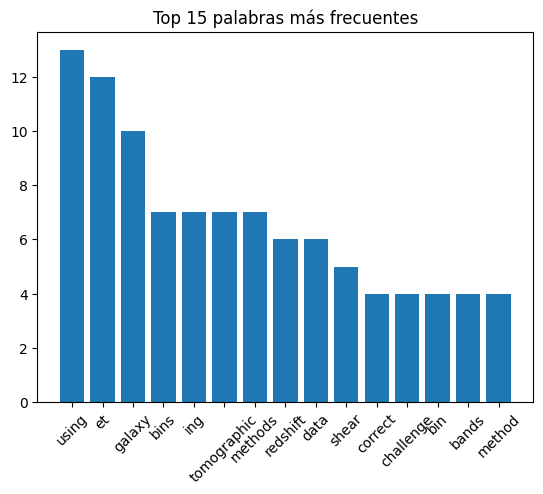

In [ ]:
# Instalación e imports
!pip install PyMuPDF
import fitz
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt
import string

nltk.download('stopwords')

# Abrir PDF
doc = fitz.open("archivo.pdf")

# Elegir una página
texto = doc[1].get_text().lower()

# Tokenización
palabras = texto.split()

# Stopwords
stop_words = set(stopwords.words('english'))

# Limpieza
palabras_limpias = [
    p.strip(string.punctuation)
    for p in palabras
    if p not in stop_words and p.isalpha()
]

# Frecuencias
conteo = Counter(palabras_limpias)
top_15 = conteo.most_common(15)

palabras_top, frecuencias = zip(*top_15)

# Gráfico
plt.bar(palabras_top, frecuencias)
plt.xticks(rotation=45)
plt.title("Top 15 palabras más frecuentes")
plt.show()

# ¿ Te surgieron en esta visualización tokens que también considerarías stop words? Comenta y justifica.

En la visualización de las 15 palabras más frecuentes, identifiqué algunos tokens como “et” que, aunque no forman parte de las stop words tradicionales, los considero como tales en este contexto. Esto se debe a que no aportan un significado relevante al contenido, sino que aparecen como parte de expresiones académicas (por ejemplo, “et.”).

## 5. Referencias

- https://arxiv.org/
- Documentación de PyMuPDF
- Documentación de pdfplumber
- Documentación de NLTK


## 6. Conclusión general

En este trabajo pude desarrollar un flujo completo para procesar un archivo PDF utilizando Python.

Primero descargué el documento y analicé sus metadatos, lo que me permitió conocer información básica del archivo. Luego extraje el texto de las primeras páginas y observé que se presenta de forma cruda, con saltos de línea y algunos caracteres especiales.

También logré extraer una tabla del documento y convertirla en un DataFrame, aunque con algunas limitaciones debido a la estructura interna del PDF.

Finalmente, realicé un análisis de frecuencias de palabras utilizando técnicas básicas de NLP, lo que permitió identificar los términos más utilizados en el texto.

En conclusión, este trabajo demuestra que es posible transformar un PDF en datos analizables, aunque el proceso puede presentar dificultades dependiendo de cómo esté estructurado el documento.